In [1]:
import pandas as pd
import tensorflow as tf
import os
from working_data import clean_cols, clean_non_minute_rows, alt_label_df as label_df, normalize_by_window, split_df, add_bollinger_bands
from data_builder_trans import bb_combined_create_dataset_generator, get_total_rows
from model_builder_trans import build_combined_bb_model, combined_loss
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

2024-10-17 18:53:24.122603: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-17 18:53:24.159223: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-17 18:53:24.869803: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2024-10-17 18:53:25.673468: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-17 18:53:25.702653: 

In [2]:
NORMALIZING_WINDOW_SIZE = 180
LABELING_WINDOW_SIZE = 20
POSITIVE_SLOPE = 0.3
LABEL_CUR_CANDLE_MULTIPLIER = 0
LABEL_MEAN_MULTIPLIER = 8
BATCH_SIZE = 32
NUM_TRANSFORMER_TOKENS = 48
D_MODEL = 32
FF_DIM = D_MODEL*2
NUM_HEADS = D_MODEL//8
NUM_TRANSFORMER_LAYERS = 2

In [3]:
source_csv = "data/GBPUSD/minutes.csv"
working_path = "working"

In [4]:
df = pd.read_csv(source_csv)
df = clean_non_minute_rows(df)
df = clean_cols(df)
df = add_bollinger_bands(df)
break_point = len(df) - len(df)//20
df = df[break_point:]
df = normalize_by_window(
    df, 
    window_size=NORMALIZING_WINDOW_SIZE, 
    normalizing_cols=[
        'open',
        'high',
        'low',
        'close',
        'upper',
        'middle',
        'lower'
    ])
print("labeling")
df = label_df(df, window_size=LABELING_WINDOW_SIZE, mean_multiplier=LABEL_MEAN_MULTIPLIER, cur_candle_multiplier=LABEL_CUR_CANDLE_MULTIPLIER)
print(df['target'].value_counts())
split_df(
    df=df, 
    dump_path=working_path, 
    cols=[
        'open_normalized',
        'high_normalized',
        'low_normalized',
        'close_normalized',
        'upper_normalized',
        'middle_normalized',
        'lower_normalized',
        'target'
    ])

labeling
target
0    426393
1     22541
Name: count, dtype: int64


In [5]:
input_shape = (NUM_TRANSFORMER_TOKENS, 4)
bb_input_shape = (NUM_TRANSFORMER_TOKENS, 3)
model = build_combined_bb_model(transformer_input_shape=input_shape, bb_input_shape=bb_input_shape, d_model=D_MODEL, ff_dim=FF_DIM, num_heads=NUM_HEADS, num_layers=NUM_TRANSFORMER_LAYERS, training=True)
auc =  tf.keras.metrics.AUC()
auc.reset_state()
prec = tf.keras.metrics.Precision()
prec.reset_state()
model.compile(optimizer='adam', 
              loss=combined_loss, 
              metrics=['accuracy',auc, prec])



In [6]:
train_file = os.path.join(working_path, 'train.csv')
val_file = os.path.join(working_path, 'val.csv')
test_file = os.path.join(working_path, 'test.csv')

train_dataset= bb_combined_create_dataset_generator(train_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS, smote=True, shuffle=True, repeat=True).prefetch(tf.data.AUTOTUNE)
val_dataset = bb_combined_create_dataset_generator(val_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS, repeat=True).prefetch(tf.data.AUTOTUNE)
test_dataset = bb_combined_create_dataset_generator(test_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS).prefetch(tf.data.AUTOTUNE)

train_steps_per_epoch = get_total_rows(train_file, smote=True, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE
val_steps_per_epoch = get_total_rows(val_file, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE
test_steps_per_epoch = get_total_rows(test_file, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE


In [7]:
for data in train_dataset.take(1):
    inputs, labels = data
    print("Inputs:", inputs[0].numpy())
    print("Inputs:", inputs[1].numpy())
    print("Labels:", labels.numpy())

Inputs: [[[0.25233644 0.27336448 0.23831776 0.24299066]
  [0.25233644 0.27102804 0.22429906 0.23831776]
  [0.23598132 0.26401868 0.20093457 0.20794393]
  ...
  [0.44392523 0.45327103 0.40420562 0.40420562]
  [0.37850466 0.39252338 0.35747662 0.38084114]
  [0.37850466 0.38084114 0.33878505 0.33878505]]

 [[0.35099337 0.35099337 0.35099337 0.35099337]
  [0.35099337 0.35099337 0.35099337 0.35099337]
  [0.35099337 0.37086093 0.28476822 0.33112583]
  ...
  [0.10625    0.19375    0.10625    0.13125   ]
  [0.1375     0.16875    0.11875    0.11875   ]
  [0.125      0.1375     0.0125     0.03125   ]]

 [[0.41322315 0.4214876  0.34710744 0.34710744]
  [0.34710744 0.3553719  0.338843   0.338843  ]
  [0.338843   0.34710744 0.23966943 0.338843  ]
  ...
  [0.8452381  0.91071427 0.83928573 0.89285713]
  [0.7389163  1.         0.72906405 0.9359606 ]
  [0.9408867  0.9408867  0.9014778  0.9014778 ]]

 ...

 [[0.184      0.208      0.104      0.112     ]
  [0.104      0.176      0.096      0.104     ]
  

2024-10-17 18:55:02.082547: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
early_stopping = EarlyStopping(monitor='val_precision_1', 
                               patience=5, # Stops if there's no improvement in precision for 5 epochs
                               mode='max', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_trans_model.keras', 
                                   monitor='val_precision_1', 
                                   save_best_only=True, 
                                   mode='max', 
                                   verbose=1)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=20,
    steps_per_epoch = train_steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=val_steps_per_epoch,
    callbacks=[early_stopping, model_checkpoint]
)


# Load the best model after training
model.load_weights('best_trans_model.keras')

Epoch 1/20


I0000 00:00:1729184109.104749  316858 service.cc:145] XLA service 0x7fec1c00d9b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1729184109.104789  316858 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2024-10-17 18:55:09.336078: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-17 18:55:10.135897: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1729184117.259565  317255 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_125', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1729184118.914145  317246 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_125', 412 bytes spill stores, 412 bytes spill loads

    3/18662 ━━━━━━━━━━━━━━━━━━━━ 12:47 41ms/step - accuracy: 0.4861 - auc: 0.5619 - loss: 0.9643 - precision_1: 0.4502   

I0000 00:00:1729184130.695445  316858 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18660/18662 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5938 - auc: 0.6300 - loss: 0.8923 - precision_1: 0.5852
Epoch 1: val_precision_1 improved from -inf to 0.07088, saving model to best_trans_model.keras
18662/18662 ━━━━━━━━━━━━━━━━━━━━ 725s 37ms/step - accuracy: 0.5938 - auc: 0.6300 - loss: 0.8923 - precision_1: 0.5852 - val_accuracy: 0.5373 - val_auc: 0.6504 - val_loss: 1.0909 - val_precision_1: 0.0709
Epoch 2/20
18661/18662 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6316 - auc: 0.6787 - loss: 0.8578 - precision_1: 0.6198
Epoch 2: val_precision_1 improved from 0.07088 to 0.07240, saving model to best_trans_model.keras
18662/18662 ━━━━━━━━━━━━━━━━━━━━ 706s 38ms/step - accuracy: 0.6316 - auc: 0.6787 - loss: 0.8578 - precision_1: 0.6198 - val_accuracy: 0.5608 - val_auc: 0.6492 - val_loss: 1.0770 - val_precision_1: 0.0724
Epoch 3/20
18660/18662 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6396 - auc: 0.6913 - loss: 0.8467 - precision_1: 0.6253
Epoch 3: val_precision_1 impr

In [9]:
predictions = model.predict(test_dataset)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)


2102/2102 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step


2024-10-17 22:07:26.661787: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
y_true = []

for input_tensor, target_tensor in test_dataset:
    y_true.extend(target_tensor.numpy()) 

2024-10-17 22:08:31.419849: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
len(predicted_class), len(y_true)

(67264, 67264)

Confusion Matrix:
 [[39919 23805]
 [ 1341  2199]]


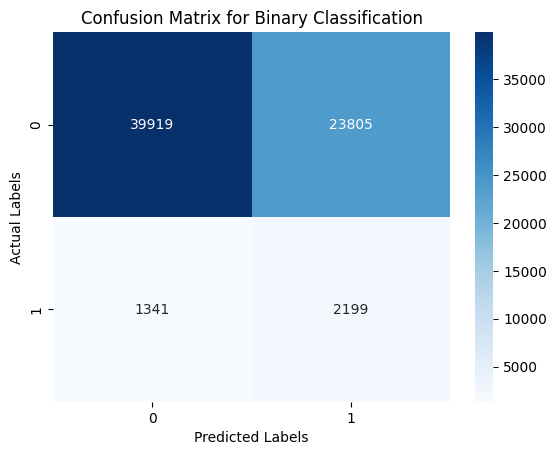

In [13]:
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Optionally: Visualize the confusion matrix using a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Binary Classification')
plt.show()

In [14]:
model.evaluate(test_dataset)

2102/2102 ━━━━━━━━━━━━━━━━━━━━ 68s 32ms/step - accuracy: 0.6403 - auc: 0.6790 - loss: 1.0031 - precision_1: 0.0935


2024-10-17 22:09:39.480401: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2024-10-17 22:09:39.480498: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2024-10-17 22:09:39.480693: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 11816260972992080733
2024-10-17 22:09:39.480749: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 14888428245950490976
2024-10-17 22:09:39.480783: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 18163542760417886036
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate 

[1.0248914957046509,
 0.6261596083641052,
 0.6651011109352112,
 0.08456391096115112]